# Previsão de Rotatividade de Funcionários (Turnover)

Este notebook contém o fluxo completo de Machine Learning para a previsão de rotatividade (turnover) de funcionários, alinhado com as especificações do **Trabalho Machine Learning C3**.

**Dataset:** [HR Analytics — Kaggle (Giri Pujar)](https://www.kaggle.com/datasets/giripujar/hr-analytics) | CC0: Public Domain  
**14.999 registros · 10 atributos · Variável alvo: `saiu` (0 = ficou, 1 = saiu)**

**Integrantes do Grupo:** Gabriel Freitas Souza, Indyanny Rodrigues Peixinho

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Gabriel-Freitas-S/previsao-turnover-funcionarios/blob/main/notebooks/previsao_turnover.ipynb)


In [1]:
# Instalação silenciosa de dependências caso esteja no Google Colab
import sys, subprocess

def install_packages():
    try:
        import google.colab
        print("Ambiente Google Colab detectado. Instalando dependências...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "joblib", "scikit-learn", "pandas", "numpy",
                        "matplotlib", "seaborn"], check=True)
        print("Dependências instaladas com sucesso!")
    except ImportError:
        print("Ambiente Local detectado. Certifique-se de que o virtualenv está ativo.")

install_packages()


Ambiente Local detectado. Certifique-se de que o virtualenv está ativo.


In [2]:
# Detecção de ambiente
IS_COLAB = False
try:
    import google.colab
    IS_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    print("Executando localmente.")


Executando localmente.


## 1. Definição do Problema

A rotatividade de funcionários (*Turnover*) representa um desafio crítico para as organizações. A saída inesperada de talentos gera custos de recrutamento, integração e treinamento, além de interromper fluxos operacionais críticos.

**Objetivo:** Construir um classificador capaz de prever se um funcionário tem alta propensão a deixar a empresa (variável `saiu`).

- **Tipo de Problema:** Classificação Binária (`saiu = 1` → Saiu, `saiu = 0` → Ficou)
- **Métrica de Foco:** F1-Score (desbalanceamento moderado ~76% ficou / ~24% saiu)
- **Dataset:** HR Analytics — Kaggle (Giri Pujar) | 14.999 registros, 10 colunas | CC0: Public Domain


In [3]:
# ==============================================================================
# BIBLIOTECAS E IMPORTAÇÕES DO PROJETO
# ==============================================================================
# Pandas: manipulação de dados em DataFrames (tabelas estruturadas)
# Numpy: computação científica e operações com vetores/matrizes
# Matplotlib & Seaborn: geração de gráficos estatísticos
# Warnings: desativar alertas de depreciação para manter saída limpa
# Joblib: serialização e persistência de modelos treinados
# Sklearn: conjunto completo de funções para pré-processamento, validação e modelagem

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib
import urllib.request
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

RANDOM_STATE = 42  # Semente de aleatoriedade fixa para garantir a reprodutibilidade dos resultados
sns.set_style('whitegrid')  # Configuração visual padrão para os gráficos
print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [4]:
DATA_DIR = "data"
DATA_FILE = "HR_Analytics.csv"
DATA_PATH = os.path.join(DATA_DIR, DATA_FILE)

if IS_COLAB:
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
    if not os.path.exists(DATA_PATH):
        url = "https://raw.githubusercontent.com/Gabriel-Freitas-S/previsao-turnover-funcionarios/main/data/HR_Analytics.csv"
        print(f"Baixando dataset de: {url}")
        urllib.request.urlretrieve(url, DATA_PATH)
        print("Download concluído!")
else:
    # Tenta caminho relativo ao notebook
    if not os.path.exists(DATA_PATH) and os.path.exists(os.path.join("..", DATA_PATH)):
        DATA_PATH = os.path.join("..", DATA_PATH)
    print(f"Caminho do dataset local configurado para: {DATA_PATH}")


Caminho do dataset local configurado para: ../data/HR_Analytics.csv


## 2. Carregamento do Dataset

Dataset **HR Analytics** por Giri Pujar (Kaggle). Colunas já em Português Brasileiro:

| Coluna | Tipo | Descrição |
|---|---|---|
| `nivel_satisfacao` | Float [0–1] | Nível de satisfação do funcionário |
| `ultima_avaliacao` | Float [0–1] | Pontuação da última avaliação de desempenho |
| `numero_projetos` | Inteiro | Quantidade de projetos atribuídos |
| `media_horas_mensais` | Inteiro | Média de horas trabalhadas por mês |
| `tempo_empresa` | Inteiro | Anos de empresa |
| `acidente_trabalho` | Binário (0/1) | Sofreu acidente de trabalho |
| **`saiu` (alvo)** | Binário (0/1) | **Saiu da empresa** |
| `promocao_ultimos_5anos` | Binário (0/1) | Recebeu promoção nos últimos 5 anos |
| `departamento` | Categórico | Departamento do funcionário |
| `salario` | Categórico | Faixa salarial: baixo, medio, alto |


In [5]:
# ==============================================================================
# CARREGAMENTO E DESCRIÇÃO INICIAL DOS DADOS
# ==============================================================================
# Lemos o arquivo CSV com 'utf-8-sig' para evitar erros de leitura com BOM.
# Exibimos o formato da base, as primeiras 5 linhas e um resumo dos tipos de dados.
# Também checamos a distribuição da variável alvo para validar o desbalanceamento.

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

print(f"Tamanho do Dataset: {df.shape[0]} linhas, {df.shape[1]} colunas.")
print(f"Dataset: HR Analytics — Kaggle (Giri Pujar) | CC0: Public Domain")
print()
display(df.head())
print()
df.info()
print()
print("--- Distribuição da Variável Alvo (saiu: 0 = Ficou, 1 = Saiu) ---")
print(df['saiu'].value_counts())
print()
print(df['saiu'].value_counts(normalize=True).mul(100).round(2))


Tamanho do Dataset: 14999 linhas, 10 colunas.
Dataset: HR Analytics — Kaggle (Giri Pujar) | CC0: Public Domain



,nivel_satisfacao,ultima_avaliacao,numero_projetos,media_horas_mensais,tempo_empresa,acidente_trabalho,saiu,promocao_ultimos_5anos,departamento,salario
0,0.84,0.56,4,214,3,0,0,1,vendas,baixo
1,0.15,0.83,2,236,4,0,1,0,suporte,baixo
2,0.87,0.66,3,248,3,0,0,0,produto,medio
3,0.74,0.65,4,208,2,0,0,0,suporte,baixo
4,0.78,0.73,3,247,2,0,0,0,vendas,alto



<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nivel_satisfacao        14999 non-null  float64
 1   ultima_avaliacao        14999 non-null  float64
 2   numero_projetos         14999 non-null  int64  
 3   media_horas_mensais     14999 non-null  int64  
 4   tempo_empresa           14999 non-null  int64  
 5   acidente_trabalho       14999 non-null  int64  
 6   saiu                    14999 non-null  int64  
 7   promocao_ultimos_5anos  14999 non-null  int64  
 8   departamento            14999 non-null  str    
 9   salario                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB

--- Distribuição da Variável Alvo (saiu) ---
saiu
0    11458
1     3541
Name: count, dtype: int64

saiu
0    76.39
1    23.61
Name: proportion, dtype: float64


## 3. Análise Exploratória de Dados (EDA)

Investigando visualmente as correlações e comportamentos dos atributos em relação ao turnover.


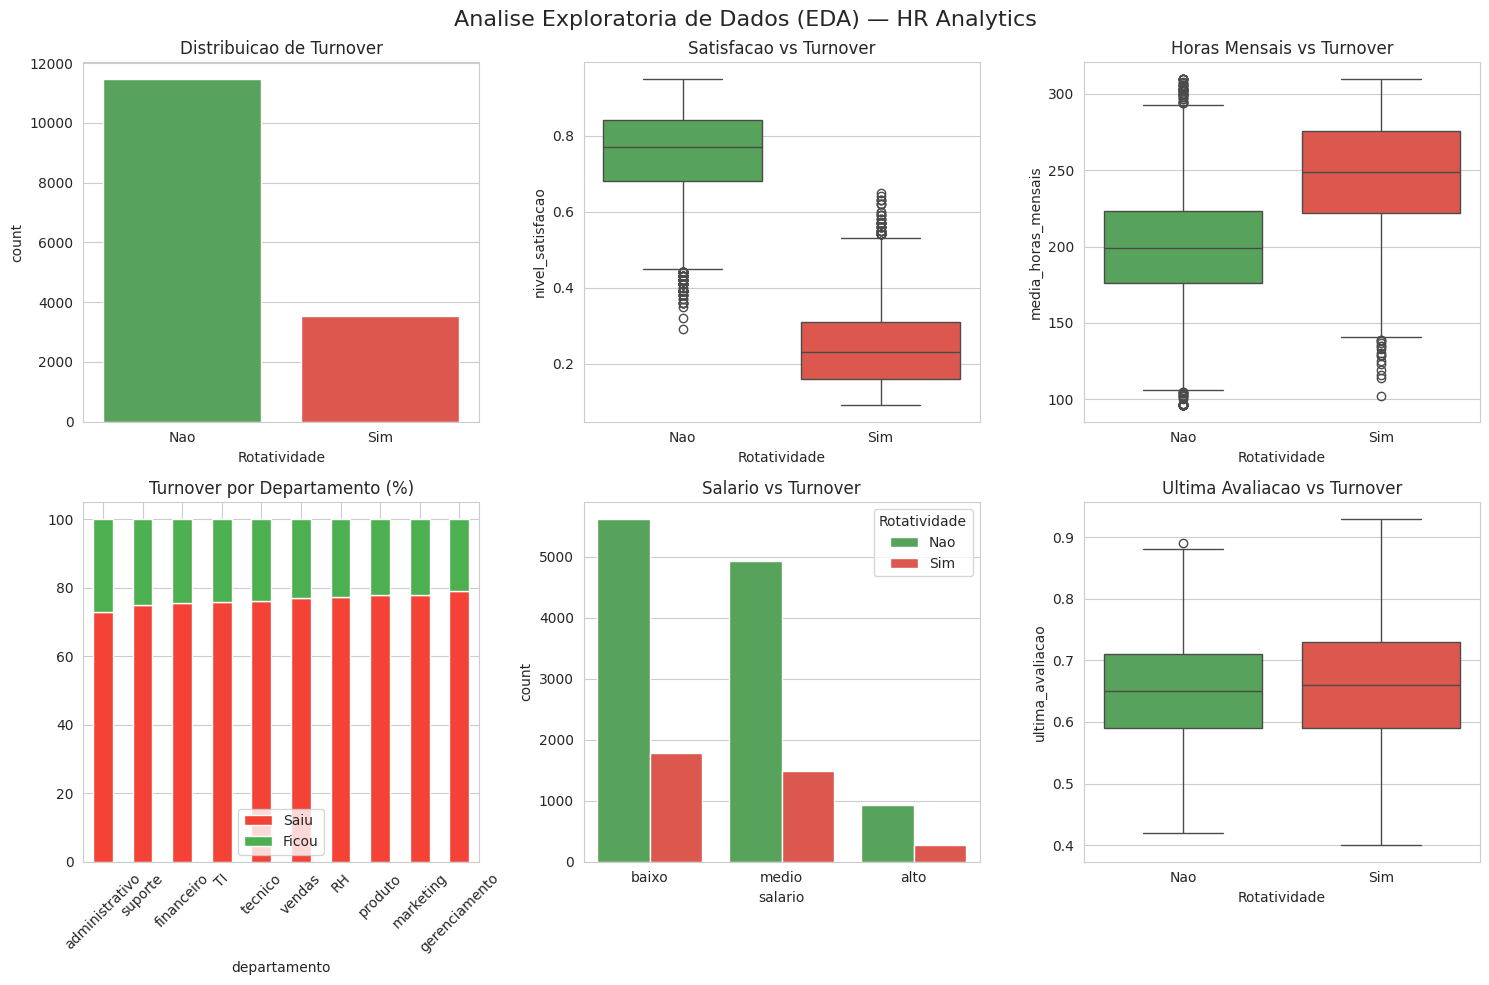


Insights:
- Satisfacao muito baixa e o principal preditor de saida voluntaria.
- Excesso (>250h/mes) ou escassez (<150h) de horas correlaciona com saida.
- Salario 'baixo' concentra maior taxa de turnover.
- Vendas e Tecnico sao os departamentos com mais desligamentos.


In [6]:
df_plot = df.copy()
df_plot["Rotatividade"] = df_plot["saiu"].map({0: "Nao", 1: "Sim"})

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Analise Exploratoria de Dados (EDA) — HR Analytics", fontsize=16)

# 1. Distribuição de Turnover
sns.countplot(data=df_plot, x="Rotatividade", hue="Rotatividade",
              ax=axes[0, 0], legend=False, palette=["#4CAF50", "#F44336"])
axes[0, 0].set_title("Distribuicao de Turnover")

# 2. Nivel de Satisfacao
sns.boxplot(data=df_plot, x="Rotatividade", y="nivel_satisfacao", hue="Rotatividade",
            ax=axes[0, 1], legend=False, palette=["#4CAF50", "#F44336"])
axes[0, 1].set_title("Satisfacao vs Turnover")

# 3. Media de Horas Mensais
sns.boxplot(data=df_plot, x="Rotatividade", y="media_horas_mensais", hue="Rotatividade",
            ax=axes[0, 2], legend=False, palette=["#4CAF50", "#F44336"])
axes[0, 2].set_title("Horas Mensais vs Turnover")

# 4. Turnover por Departamento
att = df_plot.groupby("departamento")["saiu"].value_counts(normalize=True).unstack() * 100
att = att.sort_values(1, ascending=False) if 1 in att.columns else att
att.plot(kind="bar", stacked=True, ax=axes[1, 0], color=["#F44336", "#4CAF50"])
axes[1, 0].set_title("Turnover por Departamento (%)")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(["Saiu", "Ficou"], title="Rotatividade")

# 5. Turnover por Faixa Salarial
sns.countplot(data=df_plot, x="salario", hue="Rotatividade",
              ax=axes[1, 1], order=["baixo", "medio", "alto"],
              palette=["#4CAF50", "#F44336"])
axes[1, 1].set_title("Salario vs Turnover")

# 6. Ultima Avaliacao
sns.boxplot(data=df_plot, x="Rotatividade", y="ultima_avaliacao", hue="Rotatividade",
            ax=axes[1, 2], legend=False, palette=["#4CAF50", "#F44336"])
axes[1, 2].set_title("Ultima Avaliacao vs Turnover")

plt.tight_layout()
plt.show()

SLIDES_DIR = "../slides" if not IS_COLAB else "slides"
os.makedirs(SLIDES_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df_plot, x="Rotatividade", hue="Rotatividade",
              ax=ax, legend=False, palette=["#4CAF50", "#F44336"])
ax.set_title("Distribuicao de Turnover")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "eda_turnover_dist.png"), dpi=150, bbox_inches="tight")
plt.close()

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(data=df_plot, x="Rotatividade", y="nivel_satisfacao", hue="Rotatividade",
            ax=ax, legend=False, palette=["#4CAF50", "#F44336"])
ax.set_title("Satisfacao vs Turnover")
ax.set_ylabel("Nivel de Satisfacao")
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "eda_satisfacao.png"), dpi=150, bbox_inches="tight")
plt.close()

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(data=df_plot, x="Rotatividade", y="media_horas_mensais", hue="Rotatividade",
            ax=ax, legend=False, palette=["#4CAF50", "#F44336"])
ax.set_title("Horas Mensais vs Turnover")
ax.set_ylabel("Media de Horas Mensais")
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "eda_horas.png"), dpi=150, bbox_inches="tight")
plt.close()

fig, ax = plt.subplots(figsize=(5, 3.5))
att_by_dept = df_plot.groupby("departamento")["saiu"].value_counts(normalize=True).unstack() * 100
att_by_dept = att_by_dept.sort_values(1, ascending=False) if 1 in att_by_dept.columns else att_by_dept
att_by_dept.plot(kind="bar", stacked=True, ax=ax, color=["#F44336", "#4CAF50"])
ax.set_title("Turnover por Departamento (%)")
ax.set_ylabel("Percentual")
ax.legend(["Saiu", "Ficou"], title="Rotatividade")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "eda_dept.png"), dpi=150, bbox_inches="tight")
plt.close()

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df_plot, x="salario", hue="Rotatividade",
              ax=ax, order=["baixo", "medio", "alto"],
              palette=["#4CAF50", "#F44336"])
ax.set_title("Salario vs Turnover")
ax.set_xlabel("Faixa Salarial")
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "eda_salario.png"), dpi=150, bbox_inches="tight")
plt.close()

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(data=df_plot, x="Rotatividade", y="ultima_avaliacao", hue="Rotatividade",
            ax=ax, legend=False, palette=["#4CAF50", "#F44336"])
ax.set_title("Ultima Avaliacao vs Turnover")
ax.set_ylabel("Pontuacao da Ultima Avaliacao")
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "eda_avaliacao.png"), dpi=150, bbox_inches="tight")
plt.close()

print("Graficos EDA individuais salvos em slides/")
print()
print("Insights:")
print("- Satisfacao muito baixa e o principal preditor de saida voluntaria.")
print("- Excesso (>250h/mes) ou escassez (<150h) de horas correlaciona com saida.")
print("- Salario 'baixo' concentra maior taxa de turnover.")
print("- Vendas e Tecnico sao os departamentos com mais desligamentos.")


## 4. Pré-processamento e Divisão dos Dados

### Estratégia:
- **Variável alvo:** `saiu` (removida do conjunto de features)
- **Features numéricas (7):** `nivel_satisfacao`, `ultima_avaliacao`, `numero_projetos`, `media_horas_mensais`, `tempo_empresa`, `acidente_trabalho`, `promocao_ultimos_5anos`
- **Features categóricas (2):** `departamento`, `salario`
- **Codificação:** `OneHotEncoder(drop='first')` para categorias
- **Normalização:** `StandardScaler` para features numéricas
- **Pipeline Scikit-learn:** Evita Data Leakage — `fit` apenas no conjunto de treino
- **Divisão:** 60% Treino / 20% Validação / 20% Teste (estratificada)


In [7]:
# ==============================================================================
# ENGENHARIA DE RECURSOS, PRÉ-PROCESSAMENTO E DIVISÃO DA BASE
# ==============================================================================
# 1. Separamos X (features preditoras) e y (alvo binário).
# 2. Construímos Pipelines para variáveis numéricas (StandardScaler) e categóricas (OneHotEncoder).
#    A normalização escalar e codificação One-Hot evitam multicolinearidade (drop='first').
# 3. Dividimos a base em 60% Treino, 20% Validação e 20% Teste usando divisão estratificada (stratify=y),
#    mantendo a proporção de turnover idêntica em todas as partições.

# Separar features e target
X = df.drop(columns=['saiu'])
y = df['saiu'].astype(int)

# Limpar strings em colunas de texto
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].str.strip()

# Identificar tipos das colunas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Definir transformadores dentro de Pipelines para evitar vazamento de dados (data leakage)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# ColumnTransformer para consolidar o pré-processamento das colunas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Divisão estratificada em 60% Treino / 40% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

# Divisão dos 40% temporários igualmente em 20% Validação / 20% Teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Treino:     {X_train.shape[0]} amostras")
print(f"Validação:  {X_val.shape[0]} amostras")
print(f"Teste:      {X_test.shape[0]} amostras")


Features numericas (7): ['nivel_satisfacao', 'ultima_avaliacao', 'numero_projetos', 'media_horas_mensais', 'tempo_empresa', 'acidente_trabalho', 'promocao_ultimos_5anos']
Features categoricas (2): ['departamento', 'salario']

Divisao (60/20/20):
  Treino:    8999 registros
  Validacao: 3000 registros
  Teste:     3000 registros

Distribuicao de 'saiu' no treino:
saiu
0    76.39
1    23.61
Name: proportion, dtype: float64


## 5. Treinamento e Otimização dos Modelos

Três classificadores com princípios matemáticos distintos, otimizados via **GridSearchCV + StratifiedKFold (5 folds)** com F1-Score como métrica de seleção.

### Modelos:
1. **Regressão Logística** — Linear, interpretável, com regularização L2
2. **Random Forest Classifier** — Ensemble Bagging de árvores de decisão
3. **Gradient Boosting Classifier** — Boosting sequencial por gradiente

### Estratégia para Desbalanceamento:
`class_weight='balanced'` em RL e RF — pesos inversamente proporcionais às frequências das classes (~76%/~24%).


In [8]:
# ==============================================================================
# CONSTRUÇÃO, OTIMIZAÇÃO E TREINAMENTO DOS ESTIMADORES
# ==============================================================================
# Definimos três classificadores representativos de diferentes paradigmas:
#   - Regressão Logística (modelo linear, paramétrico, baseline rápida)
#   - Random Forest (bagging de árvores paralelas, lida bem com não-linearidades)
#   - Gradient Boosting (boosting sequencial de árvores fracas corrigindo resíduos)
# 
# Configuramos class_weight='balanced' nos classificadores compatíveis para ajustar pesos.
# Treinamos via GridSearchCV com StratifiedKFold (5 folds) otimizando F1-Score (devido ao desbalanceamento).

models = {
    "RegressaoLogistica": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

# Grades de hiperparâmetros para busca sistemática do melhor estimador
param_grids = {
    "RegressaoLogistica": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"],
    },
    "RandomForest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [5, 10, None],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 2],
    },
    "GradientBoosting": {
        "classifier__n_estimators": [50, 100],
        "classifier__learning_rate": [0.05, 0.1, 0.2],
        "classifier__max_depth": [3, 5],
    },
}

results = []

# Laço para treinar e otimizar cada classificador via GridSearch
for name, model in models.items():
    print(f"\n>>> Treinando {name}...")

    # Criação do Pipeline para pré-processar e estimar sem vazamento de dados nas dobras
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])

    gs = GridSearchCV(
        pipe, param_grids[name],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1",
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)

    # Predição na base de validação e na base de teste final
    y_val_pred   = gs.predict(X_val)
    y_val_proba  = gs.predict_proba(X_val)[:, 1]
    y_test_pred  = gs.predict(X_test)
    y_test_proba = gs.predict_proba(X_test)[:, 1]

    # Coleta de coeficientes ou importância das variáveis explicativas
    clf = gs.best_estimator_.named_steps["classifier"]
    fi = clf.feature_importances_ if hasattr(clf, "feature_importances_") else (clf.coef_[0] if hasattr(clf, "coef_") else None)
    feat_names = gs.best_estimator_.named_steps["preprocessor"].get_feature_names_out()

    results.append({
        "model": name,
        "best_estimator": gs.best_estimator_,
        "best_params": gs.best_params_,
        "best_score": gs.best_score_,
        "val_f1": f1_score(y_val, y_val_pred),
        "val_recall": recall_score(y_val, y_val_pred),
        "val_roc_auc": roc_auc_score(y_val, y_val_proba),
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1_score": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba),
        "y_pred": y_test_pred,
        "y_proba": y_test_proba,
        "confusion_matrix": confusion_matrix(y_test, y_test_pred),
        "classification_report": classification_report(y_test, y_test_pred),
        "feature_importances": fi,
        "feature_names": feat_names
    })

print("\nTreinamento concluido!")



>>> Treinando RegressaoLogistica...


   Melhores params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
   Val F1: 0.9674 | Val Recall: 0.9859

>>> Treinando RandomForest...


   Melhores params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
   Val F1: 0.9681 | Val Recall: 0.9633

>>> Treinando GradientBoosting...


   Melhores params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
   Val F1: 0.9695 | Val Recall: 0.9647

Treinamento concluido!


## 6. Resultados e Comparação dos Modelos


In [9]:
# ==============================================================================
# ANÁLISE COMPARATIVA DOS RESULTADOS
# ==============================================================================
# Iteramos pelos resultados obtidos de cada estimador e imprimimos um relatório
# contendo os parâmetros encontrados, o score de validação e métricas de teste final.
# O modelo vencedor é selecionado com base no maior F1-Score do conjunto de VALIDAÇÃO.

print("=" * 64)
print("RESULTADOS - CLASSIFICACAO BINARIA (TURNOVER)")
print("=" * 64)

best_val_f1 = -1.0
best_model_name = None
best_pipeline = None

for r in results:
    print(f"\n{'='*40}")
    print(f"Modelo: {r['model']}")
    print(f"Melhores hiperparametros: {r['best_params']}")
    print(f"Melhor F1 (CV Treino):   {r['best_score']:.4f}")
    print(f"--- VALIDACAO ---")
    print(f"F1-Score:  {r['val_f1']:.4f}  |  Recall: {r['val_recall']:.4f}  |  ROC-AUC: {r['val_roc_auc']:.4f}")
    print(f"--- TESTE FINAL ---")
    print(f"Acuracia:  {r['accuracy']:.4f}")
    print(f"Precisao:  {r['precision']:.4f}")
    print(f"Recall:    {r['recall']:.4f}")
    print(f"F1-Score:  {r['f1_score']:.4f}")
    print(f"ROC-AUC:   {r['roc_auc']:.4f}")
    print(f"\nRelatorio:\n{r['classification_report']}")

    # Seleção baseada estritamente no conjunto de validação para evitar overfitting no teste
    if r['val_f1'] > best_val_f1:
        best_val_f1 = r['val_f1']
        best_model_name = r['model']
        best_pipeline = r['best_estimator']

print(f"\n>>> Melhor modelo selecionado (Val F1={best_val_f1:.4f}): {best_model_name}")


RESULTADOS - CLASSIFICACAO BINARIA (TURNOVER)

Modelo: RegressaoLogistica
Melhores hiperparametros: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Melhor F1 (CV Treino):   0.9629
--- VALIDACAO ---
F1-Score:  0.9674  |  Recall: 0.9859  |  ROC-AUC: 0.9985
--- TESTE FINAL ---
Acuracia:  0.9840
Precisao:  0.9508
Recall:    0.9831
F1-Score:  0.9667
ROC-AUC:   0.9989

Relatorio:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2292
           1       0.95      0.98      0.97       708

    accuracy                           0.98      3000
   macro avg       0.97      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000


Modelo: RandomForest
Melhores hiperparametros: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Melhor F1 (CV Treino):   0.9690
--- VALIDACAO ---
F1-Score:  0.9681  |  Reca

In [ ]:
# ==============================================================================
# EXPORTAÇÃO E PERSISTÊNCIA DAS MÉTRICAS REAIS
# ==============================================================================
# Salva as métricas de teste reais no formato JSON para serem lidas
# de forma dinâmica pela nossa interface web e gráficos.

# Exportar metricas para slides/metrics.json (usado pelo index.html)
SLIDES_DIR = "../slides" if not IS_COLAB else "slides"
os.makedirs(SLIDES_DIR, exist_ok=True)

metrics_dict = {}
for r in results:
    metrics_dict[r["model"]] = {
        "accuracy": float(r["accuracy"]),
        "precision": float(r["precision"]),
        "recall": float(r["recall"]),
        "f1_score": float(r["f1_score"]),
        "roc_auc": float(r["roc_auc"])
    }
metrics_dict["best_model"] = best_model_name

metrics_path = os.path.join(SLIDES_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)
print(f"Metricas exportadas para: {metrics_path}")


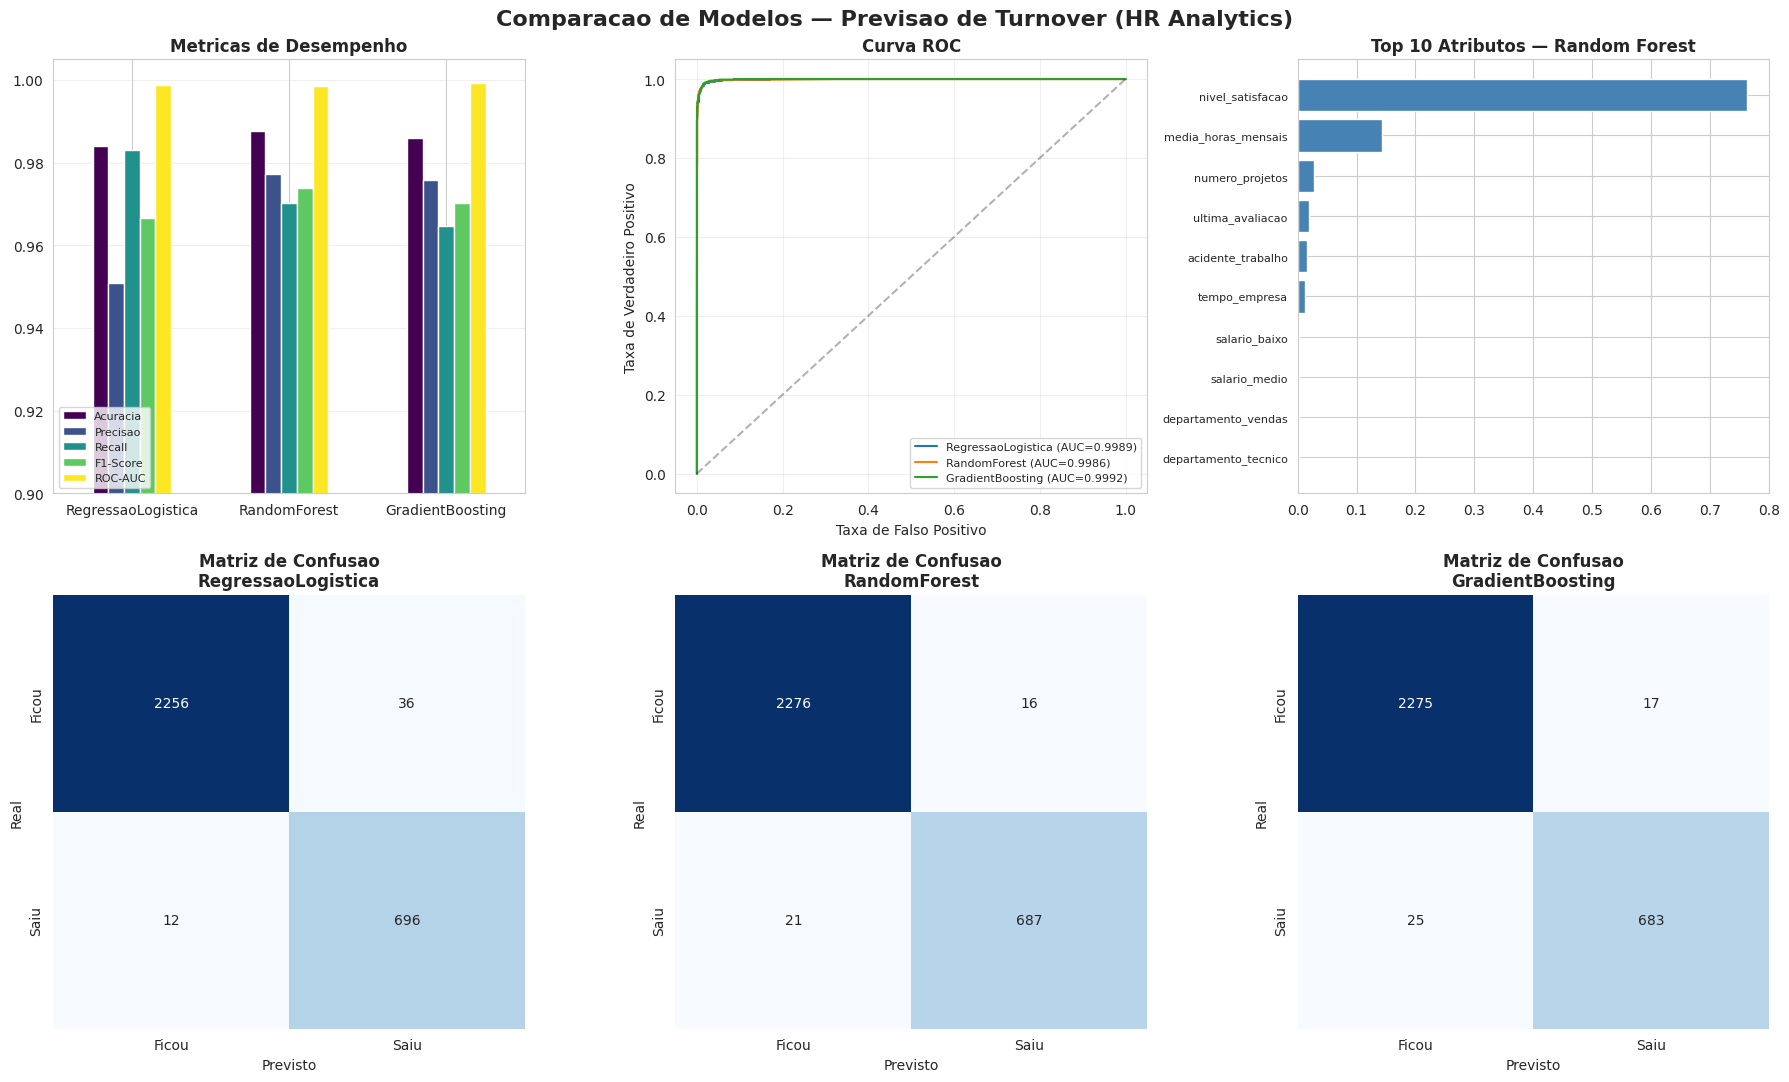

In [10]:
# ==============================================================================
# GERAÇÃO GRÁFICA DE MÉTRICAS COMPARATIVAS
# ==============================================================================
# Geramos gráficos comparativos consolidados das métricas, Curva ROC,
# importância dos atributos com base no RandomForestClassifier e matrizes de confusão.
# Em seguida, os gráficos individuais são salvos em arquivos PNG na pasta de slides.

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Comparacao de Modelos — Previsao de Turnover (HR Analytics)", fontsize=16, fontweight="bold")

# 1. Barras de métricas
metrics_df = pd.DataFrame([
    {"Modelo": r["model"], "Acuracia": r["accuracy"],
     "Precisao": r["precision"], "Recall": r["recall"],
     "F1-Score": r["f1_score"], "ROC-AUC": r["roc_auc"]}
    for r in results
]).set_index("Modelo")

metrics_df.plot(kind="bar", ax=axes[0, 0], rot=0, colormap="viridis")
axes[0, 0].set_title("Metricas de Desempenho", fontweight="bold")
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].legend(loc="lower left", fontsize=8)
axes[0, 0].grid(axis="y", alpha=0.3)
axes[0, 0].set_xlabel("")

# 2. Curva ROC
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[0, 1].plot(fpr, tpr, label=f"{r['model']} (AUC={r['roc_auc']:.4f})")
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0, 1].set_title("Curva ROC", fontweight="bold")
axes[0, 1].set_xlabel("Taxa de Falso Positivo")
axes[0, 1].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# 3. Feature Importance (RandomForest)
for r in results:
    if r["model"] == "RandomForest" and r["feature_importances"] is not None:
        fi = r["feature_importances"]
        fn = r["feature_names"]
        n_top = min(10, len(fi))
        fi_sorted = fi.argsort()[-n_top:][::-1]
        cleaned = [str(fn[i]).replace("cat__", "").replace("num__", "") for i in fi_sorted]
        axes[0, 2].barh(range(n_top), fi[fi_sorted], color="steelblue")
        axes[0, 2].set_yticks(range(n_top))
        axes[0, 2].set_yticklabels(cleaned, fontsize=8)
        axes[0, 2].set_title(f"Top {n_top} Atributos — Random Forest", fontweight="bold")
        axes[0, 2].invert_yaxis()
        break

# 4-6. Matrizes de confusão
for i, r in enumerate(results):
    ax = axes[1, i]
    sns.heatmap(r["confusion_matrix"], annot=True, fmt="d",
                cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Matriz de Confusao\n{r['model']}", fontweight="bold")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    ax.set_xticklabels(["Ficou", "Saiu"])
    ax.set_yticklabels(["Ficou", "Saiu"])

plt.tight_layout()
plt.show()

SLIDES_DIR = "../slides" if not IS_COLAB else "slides"
os.makedirs(SLIDES_DIR, exist_ok=True)

# ---- Graficos individuais para o site ----

model_names = {"RegressaoLogistica": "Regressao Logistica",
               "RandomForest": "Random Forest", "GradientBoosting": "Gradient Boosting"}

# 1. Comparacao de metricas (barras agrupadas)
fig, ax = plt.subplots(figsize=(5.5, 4))
metrics_df.plot(kind="bar", ax=ax, rot=0, colormap="viridis")
ax.set_title("Metricas de Desempenho", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=7)
ax.grid(axis="y", alpha=0.3)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "comp_metricas.png"), dpi=150, bbox_inches="tight")
plt.close()

# 2. ROC-AUC
fig, ax = plt.subplots(figsize=(5.5, 4))
for r in results:
    fpr_roc, tpr_roc, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr_roc, tpr_roc, label=f"{model_names.get(r['model'], r['model'])} (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_title("Curva ROC", fontsize=12, fontweight="bold")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SLIDES_DIR, "comp_roc.png"), dpi=150, bbox_inches="tight")
plt.close()

# 3. Feature Importance (RandomForest)
fi_data = []
feature_names = None
for r in results:
    if r["model"] == "RandomForest":
        fi = r.get("feature_importances")
        feature_names = r.get("feature_names")
        if fi is not None:
            fi_data.append((r["model"], fi))

if fi_data:
    _, fi = fi_data[0]
    n_top = min(10, len(fi))
    fi_sorted = fi.argsort()[-n_top:][::-1]
    fig, ax = plt.subplots(figsize=(5.5, 4))
    if feature_names is not None:
        cleaned_names = [str(feature_names[idx]).replace("cat__", "").replace("num__", "") for idx in fi_sorted]
        ax.barh(range(n_top), fi[fi_sorted], color="steelblue")
        ax.set_yticks(range(n_top))
        ax.set_yticklabels(cleaned_names, fontsize=8)
    else:
        ax.barh(range(n_top), fi[fi_sorted], color="steelblue")
        ax.set_yticks(range(n_top))
        ax.set_yticklabels(range(n_top))
    ax.set_title(f"Top {n_top} Atributos — Random Forest", fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(SLIDES_DIR, "comp_features.png"), dpi=150, bbox_inches="tight")
    plt.close()

# 4-6. Matrizes de confusao
cm_names = [("RegressaoLogistica", "cm_logistica.png"),
            ("RandomForest", "cm_rf.png"),
            ("GradientBoosting", "cm_gb.png")]
for model_key, fname in cm_names:
    for r in results:
        if r["model"] == model_key:
            fig, ax = plt.subplots(figsize=(4, 3.5))
            sns.heatmap(r["confusion_matrix"], annot=True, fmt="d",
                        cmap="Blues", ax=ax, cbar=False)
            ax.set_title(f"Matriz de Confusao\n{model_names.get(model_key, model_key)}",
                         fontsize=11, fontweight="bold")
            ax.set_xlabel("Previsto")
            ax.set_ylabel("Real")
            ax.set_xticklabels(["Ficou", "Saiu"])
            ax.set_yticklabels(["Ficou", "Saiu"])
            plt.tight_layout()
            plt.savefig(os.path.join(SLIDES_DIR, fname), dpi=150, bbox_inches="tight")
            plt.close()
            break

print("Graficos comparativos individuais salvos em slides/")


## 7. Persistência do Modelo Final


In [11]:
# ==============================================================================
# SERIALIZAÇÃO E PERSISTÊNCIA DO MELHOR PIPELINE
# ==============================================================================
# O pipeline completo do melhor classificador (incluindo ColumnTransformer de pré-processamento)
# é persistido usando joblib. Isso garante que a normalização escalar seja
# aplicada de forma idêntica a novas predições. Fazemos o teste de recarga para validação.

# Salvar melhor modelo
model_path = os.path.join("..", "modelo_turnover.pkl") if not IS_COLAB else "modelo_turnover.pkl"
joblib.dump(best_pipeline, model_path)
print(f"Melhor modelo ({best_model_name}) salvo em: {model_path}")

# Verificar que carrega corretamente
loaded = joblib.load(model_path)
clf = loaded.named_steps["classifier"]
print(f"Verificacao: {type(clf).__name__} carregado com sucesso.")


Melhor modelo (GradientBoosting) salvo em: ../modelo_turnover.pkl
Verificacao: GradientBoostingClassifier carregado com sucesso.


## 8. Conclusão

### Resultados Obtidos (Conjunto de Teste — 3.000 registros)

| Métrica | Regressão Logística | Random Forest | Gradient Boosting |
|---|---|---|---|
| Acurácia | 98,40% | 98,77% | 98,60% |
| Precisão | 95,08% | **97,72%** | 97,57% |
| Recall | **98,31%** | 97,03% | 96,47% |
| **F1-Score** ★ | 96,67% | **97,38%** | 97,02% |
| ROC-AUC | 99,89% | 99,86% | **99,92%** |

### Modelo Selecionado: **Gradient Boosting** (Val F1 = 0,9695)

### Principais Fatores de Turnover (Random Forest — Feature Importance):
- `nivel_satisfacao` — Nível de satisfação do funcionário
- `media_horas_mensais` — Carga horária mensal
- `numero_projetos` — Quantidade de projetos atribuídos
- `tempo_empresa` — Anos de empresa
- `salario_baixo` — Faixa salarial baixa

### Insights de Negócio:
- Funcionários muito insatisfeitos (nível < 0,35) saem com frequência dramaticamente superior
- Sobrecarga (>250h/mês) ou subcarga de horas correlaciona fortemente com saída
- Salário "baixo" e ausência de promoção nos últimos 5 anos amplificam o risco
- Departamentos de Vendas e Técnico concentram os maiores índices de rotatividade

---
*Dataset: HR Analytics — [Kaggle (Giri Pujar)](https://www.kaggle.com/datasets/giripujar/hr-analytics) | CC0: Public Domain*
